# Synthetic data engineering

### THETA, MU, SIGMA_SAFE, SIGMA_DANGER, P_SAFE_SAFE, P_DANGER_DANGER, JUMP_PROB, JUMP_STD

### $$\Delta S_t = \theta (\mu - S_{t-1}) + \sigma_{R_t} \epsilon_t + J_t$$

### Imports

In [1]:
import os, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath('../scripts'))

from synthetic import SYNTHETIC
from spread import SPREAD
from descriptive import DESCRIPTIVE

### Define ground truth parameters

In [2]:
# --- GLOBAL ARCHITECTURE ---
N_TICKS = 250000
START_DATE = "2026-01-01"
SYMBOL_A = "SYN_A"
SYMBOL_B = "SYN_B"
RANDOM_SEED = 42

# --- MICROSTRUCTURE ---
MEDIAN_SPREAD_BPS = 0.8
AVG_VOLUME = 1.5

# --- THE GROUND TRUTH (MATH) ---
THETA = 0.05            # Speed of mean reversion
MU = 0.0                # Equilibrium spread level
SIGMA_SAFE = 0.0001     # Volatility during Regime 0
SIGMA_DANGER = 0.0004   # Volatility during Regime 1
P_SAFE_SAFE = 0.999     # Probability of staying in Safe regime
P_DANGER_DANGER = 0.995 # Probability of staying in Danger regime
JUMP_PROB = 0.0002      # Probability of a micro-structure freak tick
JUMP_STD = 0.005        # The size/violence of the freak tick

### Generate the paths

In [3]:
# Instantiate the generator (simulating ~1 month of heavy tick data)
generator = SYNTHETIC(
    n_ticks=N_TICKS, 
    start_date=START_DATE, 
    symbol_a=SYMBOL_A, 
    symbol_b=SYMBOL_B,
    random_seed=RANDOM_SEED 
)

# Generate the hidden math
true_df = generator.generate_market(theta=THETA, mu=MU, sigma_0=SIGMA_SAFE, sigma_1=SIGMA_DANGER, p_00=P_SAFE_SAFE, p_11=P_DANGER_DANGER, jump_prob=JUMP_PROB, jump_std=JUMP_STD)

Generating 250000 synthetic ticks...


### Plotting

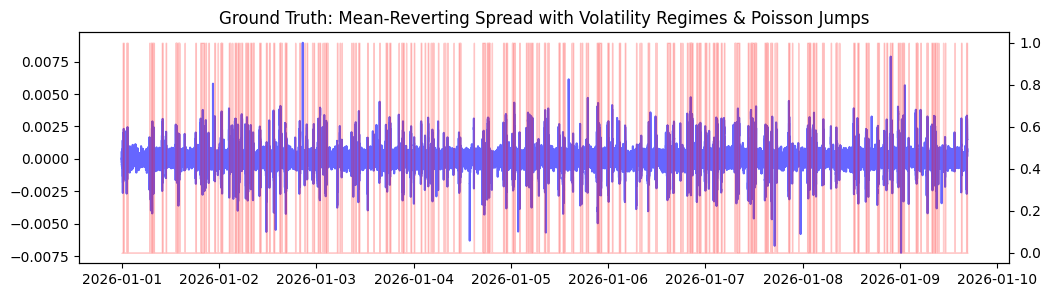

In [4]:
# Plot the hidden states to prove our math works
fig, ax1 = plt.subplots(figsize=(12, 3))
ax1.plot(true_df['datetime'], true_df['true_spread'], color='blue', alpha=0.6, label='True Spread')
ax2 = ax1.twinx()
ax2.fill_between(true_df['datetime'], 0, true_df['true_state'], color='red', alpha=0.2, label='Hidden Danger Regime')
ax1.set_title("Ground Truth: Mean-Reverting Spread with Volatility Regimes & Poisson Jumps")
plt.show()

### Save to parquet

In [5]:
# Apply Bid/Ask bounces and save to disk
synthetic_files = generator.save_to_parquets(output_dir="../data/synthetic")

# Let's look at what we created
test_read = pd.read_parquet(synthetic_files[0])
print("\nParquet Schema Check:")
display(test_read.head())

Saved 4 Parquet files to ../data/synthetic

Parquet Schema Check:


,datetime,symbol,price_type,price,volume
0,2026-01-01 00:00:00+00:00,SYN_A,ASK,1.000059,1.66
1,2026-01-01 00:00:09.030364293+00:00,SYN_A,ASK,1.000032,1.04
2,2026-01-01 00:00:12.980601373+00:00,SYN_A,ASK,1.000065,1.36
3,2026-01-01 00:00:15.719429035+00:00,SYN_A,ASK,1.000018,1.32
4,2026-01-01 00:00:16.228303646+00:00,SYN_A,ASK,1.000245,1.95


### Run the sanity check

built 575 rows


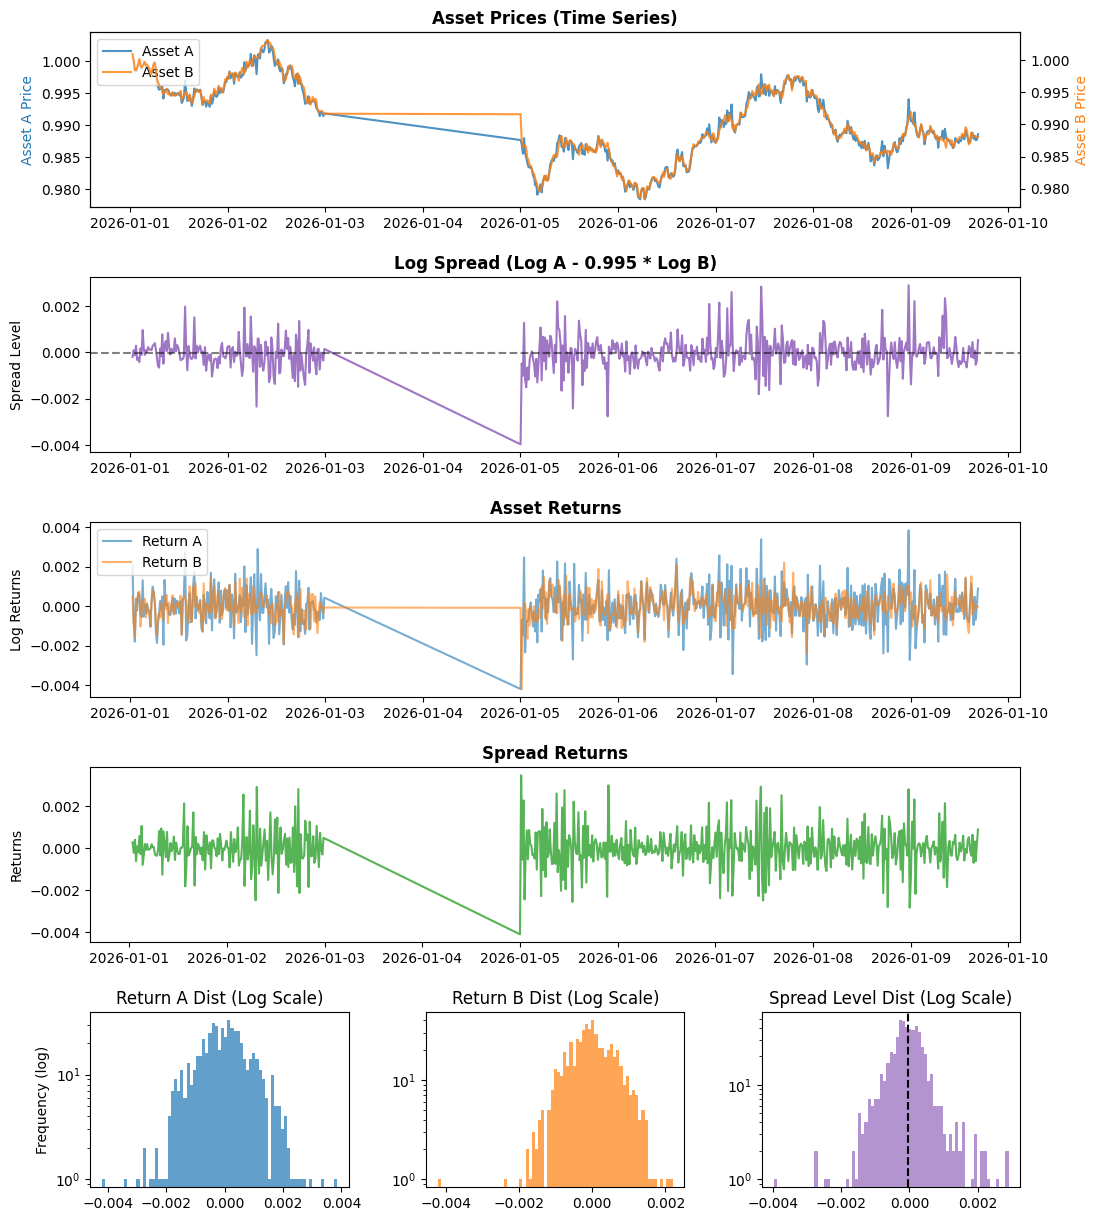

In [6]:
# If your SPREAD class accepts this without crashing, your sandbox is perfectly integrated
builder = SPREAD(agg_type='volume', threshold=1000, active_hours=(0, 24)) 
df_synth = builder.build(synthetic_files)

# Use your existing diagnostics!
builder.plot_diagnostics()

### Visual proof


=== LIQUIDITY PROFILE (Median Spreads) ===
Tightest 4h Window: 15:00 to 18:00 UTC
Overall Median Spread: A=0.40 | B=0.40 bps


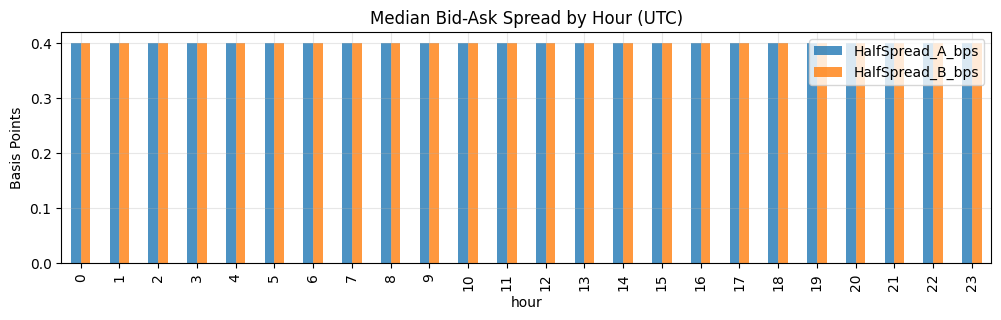


=== RETURN STATISTICS (Log Scale) ===
       Mean (bps)  Vol (bps)      Skew  Kurtosis
SYN_A   -0.175746  10.096548 -0.009625  0.884101
SYN_B   -0.216958   7.017133 -0.301963  2.048491


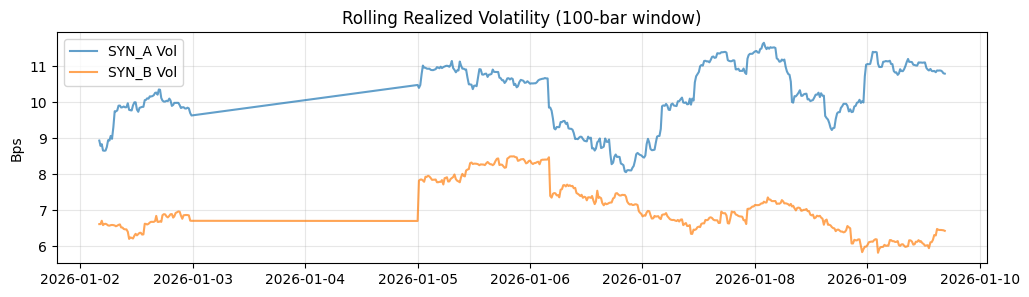

In [7]:
# Run your Descriptive Stats. 
# We WANT to see high Kurtosis here. If we do, it means our synthetic jumps 
# successfully mimic the real-world anomalies that break the Markov model.
eda = DESCRIPTIVE(df_synth, name_a="SYN_A", name_b="SYN_B")
eda.generate_full_eda()